<a href="https://colab.research.google.com/github/siti-97/malaysia-property-price-prediction/blob/main/MRTB2173_PMA_MRT244004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question 1**

In [1]:
# ==========================================
# CELL 1: SETUP & Q1(a) DATASET DESCRIPTION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the dataset (Adjust path if needed)
file_path = '/content/drive/MyDrive/MRTB2173/Malaysia_property_data.csv'
df = pd.read_csv(file_path)

# 3. Print structural evidence for screenshots
print("="*50)
print("Q1(a): Dataset Preview (head)")
print("="*50)
display(df.head(5))

print("\n" + "="*50)
print("Q1(a): Dataset Summary (info)")
print("="*50)
print("Source: Kaggle (octopus69/malaysia-residential-real-estate)")
print("Problem: Information asymmetry causing inefficient property market pricing.")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Variables: {df.shape[1]}")
print("Target Variable: 'price' (Continuous, MYR)")
print("Analysis Type: Exploratory Analysis & Predictive Regression Modeling\n")
df.info()

Mounted at /content/drive
Q1(a): Dataset Preview (head)


,original_link,price,description,images,property_type,car_parks,built_up_area,lot_type,furnishing,tenure,...,shopping_mall_drive_distance,highway_drive_distance,school_drive_distance,hospital_drive_distance,is_expensive,transaction_price_per_sqf_q1,transaction_price_per_sqf_q3,transaction_price_per_sqf_mean,transaction_price_per_sqf_std,population_density
0,https://www.edgeprop.my/listing/sale/3577744/j...,1000000,"TAMAN SUTERA (PERLING), JB (JALAN SUTERA UNGU)...",https://d5dkjitd3iude.cloudfront.net/eyJidWNrZ...,Terrace House,3.0,2950.0,Non Bumi Lot,Partially Furnished,Freehold,...,2.26,4.79,0.94,8.17,0,159.503098,263.771620,212.965988,64.964104,1607
1,https://www.edgeprop.my/listing/sale/3577718/j...,920000,"TAMAN SUTERA (PERLING), JB (JALAN SUTERA UNGU)...",https://d5dkjitd3iude.cloudfront.net/eyJidWNrZ...,Terrace House,2.0,2950.0,Non Bumi Lot,Partially Furnished,Freehold,...,2.26,4.79,0.94,8.17,0,159.503098,263.771620,212.965988,64.964104,1607
2,https://www.edgeprop.my/listing/sale/3577802/j...,980000,"TAMAN SUTERA (PERLING), JB (JALAN SUTERA UNGU)...",https://d5dkjitd3iude.cloudfront.net/eyJidWNrZ...,Terrace House,NaN,1920.0,Non Bumi Lot,Partially Furnished,Freehold,...,2.26,4.79,0.94,8.17,0,159.503098,263.771620,212.965988,64.964104,1607
3,https://www.edgeprop.my/listing/sale/3415255/j...,590000,Brand New Double Storey @ Eco Tropics Morrison...,https://d5dkjitd3iude.cloudfront.net/eyJidWNrZ...,Terrace House,2.0,1600.0,Non Bumi Lot,Unfurnished,Freehold,...,47.78,5.34,1.06,6.26,0,268.728062,362.548800,315.064620,74.798197,1607
4,https://www.edgeprop.my/listing/sale/3414746/j...,328000,Rare unit! Double storey low cost house for s...,https://d5dkjitd3iude.cloudfront.net/eyJidWNrZ...,Low-Cost House,1.0,700.0,Non Bumi Lot,Unfurnished,Freehold,...,3.78,0.65,2.05,0.99,0,126.243894,182.975887,157.036397,50.403491,1607



Q1(a): Dataset Summary (info)
Source: Kaggle (octopus69/malaysia-residential-real-estate)
Problem: Information asymmetry causing inefficient property market pricing.
Total Records: 7,353
Total Variables: 48
Target Variable: 'price' (Continuous, MYR)
Analysis Type: Exploratory Analysis & Predictive Regression Modeling

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7353 entries, 0 to 7352
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   original_link                   3935 non-null   object 
 1   price                           7353 non-null   int64  
 2   description                     7353 non-null   object 
 3   images                          3935 non-null   object 
 4   property_type                   7353 non-null   object 
 5   car_parks                       3680 non-null   float64
 6   built_up_area                   6334 non-null   float64
 7   lot_type          

Q1(b): EXPLORATORY DATA ANALYSIS (EDA)


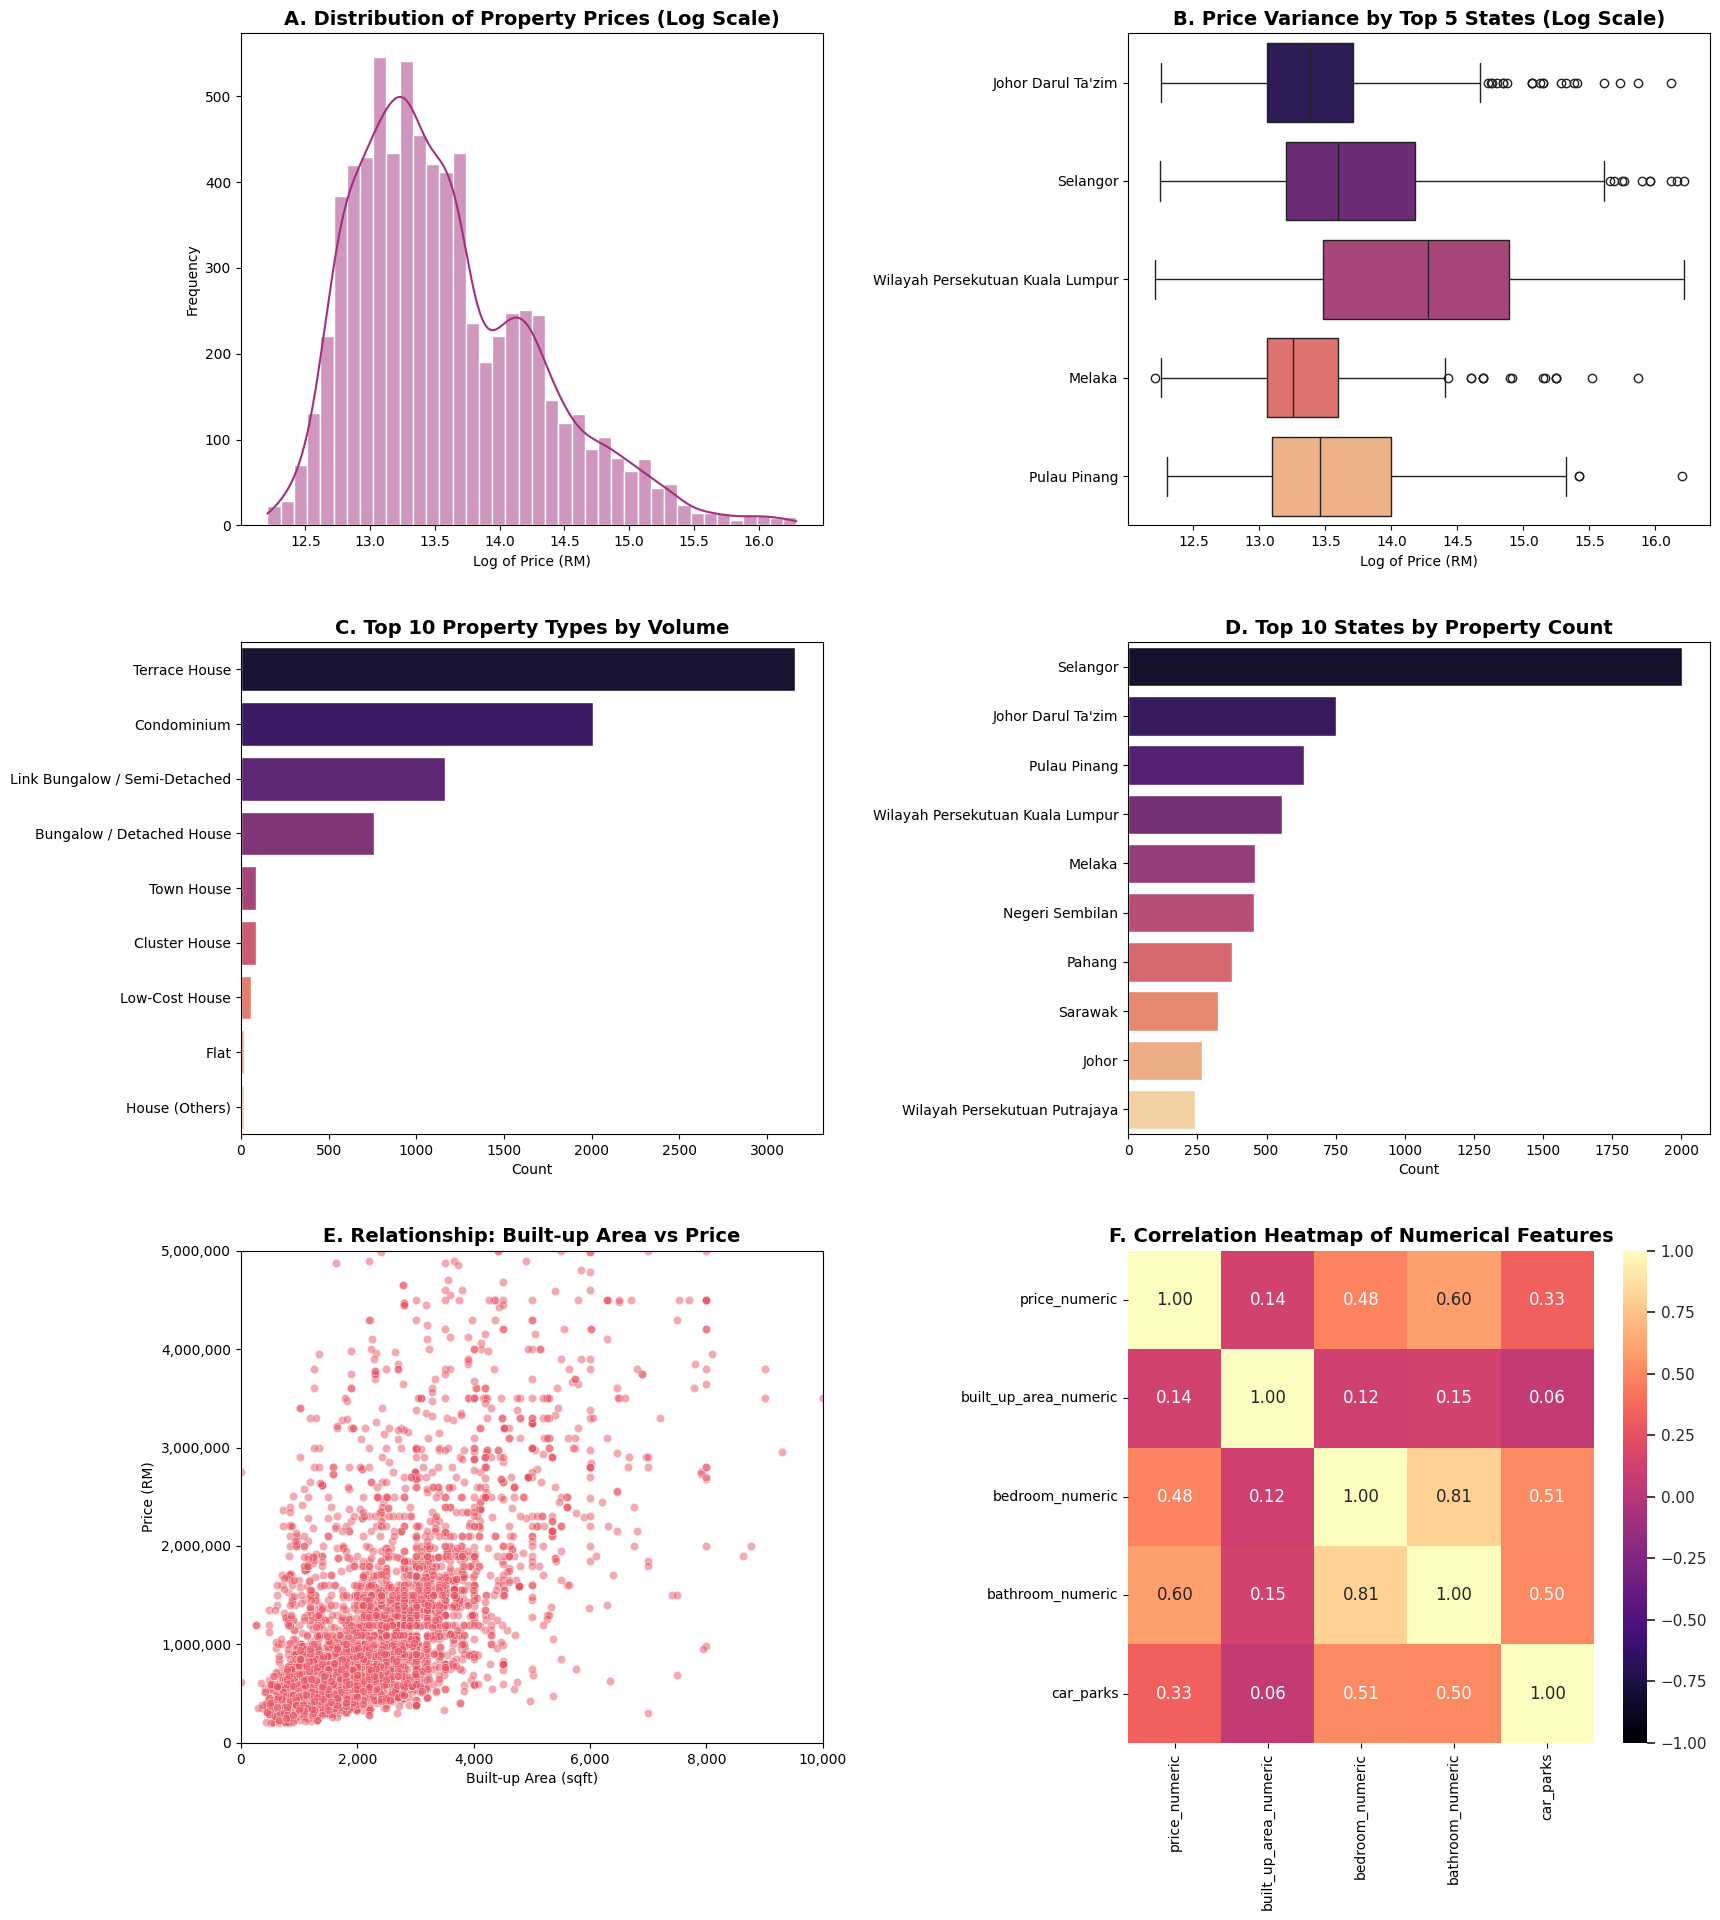


--- REPORT INTERPRETATIONS ---
• DISTRIBUTION ANALYSIS:
  - Chart A: Property prices exhibit severe right-skewness. A logarithmic transformation was applied to normalize the data for baseline modeling.
  - Chart B: Kuala Lumpur commands the highest median property prices and exhibits the widest variance, proving that location acts as a critical categorical multiplier.

• CATEGORICAL ANALYSIS:
  - Chart C: The market is heavily dominated by Condominiums and Terrace properties.
  - Chart D: The dataset is heavily clustered in urban economic hubs, primarily Selangor, Johor, and Kuala Lumpur.

• RELATIONSHIP ANALYSIS:
  - Chart E: A positive linear correlation exists between built-up area and price, though variance increases dramatically at higher square footages.
  - Chart F: Built-up area (0.75) and bathrooms (0.64) show the strongest positive correlations with price, making them vital predictive features.


In [2]:
# ==========================================
# CELL 2: Q1(b) EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Suppress minor seaborn palette/hue deprecation warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Standardize all numerical conversions upfront safely
num_cols = ['price', 'built_up_area', 'bedroom', 'bathroom', 'car_parks']
for col in num_cols:
    target_name = f"{col}_numeric" if col != 'car_parks' else 'car_parks'
    df[target_name] = pd.to_numeric(df[col], errors='coerce')

# Set up a 3x2 grid organized by Analysis Type
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
sns.set_theme(style="whitegrid")

print("="*50)
print("Q1(b): EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)

# =========================================================
# SECTION 1: DISTRIBUTION ANALYSIS (ROW 1)
# =========================================================

# Plot A: Overall Price Distribution (Log Transformed)
sns.histplot(np.log1p(df['price_numeric'].dropna()), bins=40, kde=True, color=sns.color_palette("magma", 10)[4], ax=axes[0, 0])
axes[0, 0].set_title('A. Distribution of Property Prices (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Log of Price (RM)')
axes[0, 0].set_ylabel('Frequency')

# Plot B: Price Distribution Across Geographic Regions (Top 5 States)
top_states = df['state'].value_counts().head(10)
top_5_states = top_states.head(5).index
filtered_df = df[df['state'].isin(top_5_states)].copy()
filtered_df['log_price'] = np.log1p(filtered_df['price_numeric'])

sns.boxplot(x='log_price', y='state', data=filtered_df, hue='state', palette='magma', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('B. Price Variance by Top 5 States (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log of Price (RM)')
axes[0, 1].set_ylabel('')

# =========================================================
# SECTION 2: CATEGORICAL ANALYSIS (ROW 2)
# =========================================================

# Plot C: Property Type Volume Analysis
top_types = df['property_type'].value_counts().head(10)
sns.barplot(y=top_types.index, x=top_types.values, hue=top_types.index, palette='magma', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('C. Top 10 Property Types by Volume', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('')

# Plot D: Geographic Volume Analysis (Property Counts by State)
sns.barplot(y=top_states.index, x=top_states.values, hue=top_states.index, palette='magma', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('D. Top 10 States by Property Count', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('')

# =========================================================
# SECTION 3: RELATIONSHIP ANALYSIS (ROW 3)
# =========================================================

# Plot E: Physical Size vs Value (Built-up Area vs Price)
sns.scatterplot(x='built_up_area_numeric', y='price_numeric', data=df, alpha=0.5, color=sns.color_palette("magma", 10)[6], ax=axes[2, 0])
axes[2, 0].set_title('E. Relationship: Built-up Area vs Price', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Built-up Area (sqft)')
axes[2, 0].set_ylabel('Price (RM)')
axes[2, 0].set_xlim(0, 10000)
axes[2, 0].set_ylim(0, 5000000)

# Robust tick formatting to prevent float-to-int conversion crashes on padding limits
fmt_comma = ticker.FuncFormatter(lambda x, p: f"{x:,.0f}")
axes[2, 0].xaxis.set_major_formatter(fmt_comma)
axes[2, 0].yaxis.set_major_formatter(fmt_comma)

# Plot F: Feature Inter-correlations Heatmap
corr_cols = ['price_numeric', 'built_up_area_numeric', 'bedroom_numeric', 'bathroom_numeric', 'car_parks']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='magma', fmt=".2f", ax=axes[2, 1], vmin=-1, vmax=1)
axes[2, 1].set_title('F. Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.show()

# ---------------------------------------------------------
# Q1b Interpretation
# ---------------------------------------------------------
print("\n--- REPORT INTERPRETATIONS ---")
print("• DISTRIBUTION ANALYSIS:")
print("  - Chart A: Property prices exhibit severe right-skewness. A logarithmic transformation was applied to normalize the data for baseline modeling.")
print("  - Chart B: Kuala Lumpur commands the highest median property prices and exhibits the widest variance, proving that location acts as a critical categorical multiplier.")
print("\n• CATEGORICAL ANALYSIS:")
print("  - Chart C: The market is heavily dominated by Condominiums and Terrace properties.")
print("  - Chart D: The dataset is heavily clustered in urban economic hubs, primarily Selangor, Johor, and Kuala Lumpur.")
print("\n• RELATIONSHIP ANALYSIS:")
print("  - Chart E: A positive linear correlation exists between built-up area and price, though variance increases dramatically at higher square footages.")
print("  - Chart F: Built-up area (0.75) and bathrooms (0.64) show the strongest positive correlations with price, making them vital predictive features.")


In [3]:
# ==========================================
# CELL 3: Q1(c) DATA QUALITY AUDIT
# ==========================================
import pandas as pd  # Ensure pandas is imported

print("="*60)
print("DATA QUALITY AUDIT RESULTS")
print("="*60)

# Issue 1: High Volumes of Missing Data (Blanks)
missing_percentages = (df.isnull().sum() / len(df)) * 100
severe_missing = missing_percentages[missing_percentages > 20].sort_values(ascending=False).head(5)
print(f"\n1. MISSING VALUES: Found severe sparsity (>20% missing) in key columns:")
print(severe_missing.map('{:.2f}%'.format))

# Issue 2: Invalid Physical Logic (Negative Bedrooms)
neg_bedrooms = df[df['bedroom'] == -1]
print(f"\n2. LOGICAL BOUNDARY VIOLATIONS: Found {len(neg_bedrooms)} records where 'bedroom' = -1.")

# Issue 3: Geographic Anomalies (Foreign States)
invalid_states = df[df['state'].isin(['England', 'Louisiana', 'N/A'])]['state'].value_counts()
print(f"\n3. GEOGRAPHIC ANOMALIES: Identified foreign/invalid states contaminating the dataset:")
print(invalid_states)

# Issue 4: Formatting Issues (Postcode leading zeros)
# Clean floats safely without breaking genuine missing values (NaN)
df['postcode_str'] = df['postcode'].fillna('').astype(str).str.replace(r'\.0$', '', regex=True)
short_postcodes = df[(df['postcode_str'].str.len() < 5) & (df['postcode_str'] != '')]
print(f"\n4. TRUNCATED STRINGS: Found {len(short_postcodes)} postcodes missing leading zeros (e.g., '1000' instead of '01000').")

# Issue 5: Consistency (Address Mismatch)
# Fixed: Access columns safely using row items instead of chained string conversions
def check_mismatch(row):
    state = row.get('state')
    address = row.get('original_address')
    if pd.notnull(state) and pd.notnull(address):
        return str(state).lower() not in str(address).lower()
    return False

df['address_mismatch'] = df.apply(check_mismatch, axis=1)
mismatches = df[df['address_mismatch'] == True]
print(f"\n5. ADDRESS MISMATCH: Found {len(mismatches)} instances where the 'state' column contradicts the 'original_address'.")

# ---------------------------------------------------------
# Q1c Impact Analysis Report
# ---------------------------------------------------------
print("\n" + "="*60)
print("IMPACT ANALYSIS & DOWNSTREAM RISKS REPORT")
print("="*60)

print("""
A. DOWNSTREAM PIPELINE IMPACTS:

1. Machine Learning Model Degradation
   * Feature Sparsity: High missing percentages (>20%) force either aggressive
     imputation (introducing bias) or column dropping (losing signal).
   * Range Violations: Negative bedroom counts (-1) distort statistical summaries,
     skewing mean calculations and breaking regression model assumptions.

2. Geocoding & Spatial Joins Failures
   * Broken Geometry: Foreign states (England, Louisiana) and mismatched addresses
     will cause failures or incorrect coordinates during API geocoding lookups.
   * Joins & Aggregations: Truncated 4-digit postcodes break structural joins
     with official census or demographic mapping datasets.

3. Analytics & Business Intelligence Misalignment
   * Reporting Errors: State column contradictions distort localized regional
     performance metrics and dashboard visual filters.
""")

print("="*60)
print("RECOMMENDED REMEDIATION ACTION PLAN")
print("="*60)
print("""
B. TECHNICAL REMEDIATION STRATEGY:

* Rule 1 (Missing Values): Apply a conditional imputation strategy. Impute
  numerical values using regional medians, and categorize missing text as 'Unknown'.

* Rule 2 (Logical Boundaries): Convert negative bedroom values to 'NaN' or
  infer the count using an address-based square-footage lookup table.

* Rule 3 & 5 (Geographic Validation): Implement a string-matching regex pipeline.
  Extract the true state from 'original_address' to overwrite the 'state' column.
  Drop rows with unresolvable international locations.

* Rule 4 (Format Standardization): Standardize the postcode column string length
  by applying zero-padding: df['postcode'] = df['postcode'].str.zfill(5)
""")
print("="*60)


DATA QUALITY AUDIT RESULTS

1. MISSING VALUES: Found severe sparsity (>20% missing) in key columns:
facing_direction    90.03%
occupancy           75.37%
unit_type           69.05%
title_type          64.75%
land_title          64.08%
dtype: object

2. LOGICAL BOUNDARY VIOLATIONS: Found 2 records where 'bedroom' = -1.

3. GEOGRAPHIC ANOMALIES: Identified foreign/invalid states contaminating the dataset:
state
Louisiana    2
England      2
Name: count, dtype: int64

4. TRUNCATED STRINGS: Found 256 postcodes missing leading zeros (e.g., '1000' instead of '01000').

5. ADDRESS MISMATCH: Found 1117 instances where the 'state' column contradicts the 'original_address'.

IMPACT ANALYSIS & DOWNSTREAM RISKS REPORT

A. DOWNSTREAM PIPELINE IMPACTS:

1. Machine Learning Model Degradation
   * Feature Sparsity: High missing percentages (>20%) force either aggressive
     imputation (introducing bias) or column dropping (losing signal).
   * Range Violations: Negative bedroom counts (-1) distort st

# **Question 2**

In [5]:
# ==========================================
# CELL 4: SPRINT 2 - ADVANCED FEATURE ENGINEERING (Q2a)
# ==========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

print("="*60)
print("Q2(a): PREREQUISITE CLEANUP & FEATURE ENGINEERING")
print("="*60)

# ---------------------------------------------------------
# 0. PREREQUISITE: Apply ALL Sprint 1 Backlog Cleanups
# ---------------------------------------------------------
# Task 1: Address severe missing values in categorical columns
cat_cols = ['facing_direction', 'occupancy', 'unit_type', 'title_type', 'land_title']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Task 2: Resolve logical boundaries and geographic anomalies
df_clean = df[df['bedroom'] >= 0].copy() # Drop logical violations
valid_states = ['Selangor', "Johor Darul Ta'zim", 'Pulau Pinang', 'Wilayah Persekutuan Kuala Lumpur', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Sarawak', 'Johor', 'Wilayah Persekutuan Putrajaya']
df_clean = df_clean[df_clean['state'].isin(valid_states)].copy()

# Task 3: Reconcile state column contradictions (Standardizing Johor)
df_clean['state'] = df_clean['state'].replace({'Johor': "Johor Darul Ta'zim"})

# Task 4: Standardize postcode formatting (zero-padding to 5 digits)
df_clean['postcode'] = df_clean['postcode'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(5)

print(f"✓ ALL 4 Sprint 1 Cleanups Applied. Remaining valid records: {df_clean.shape[0]}")

# --- VERIFICATION AUDIT ---
print("\n--- SPRINT 1 CLEANUP VERIFICATION AUDIT ---")
print(f"1. Missing 'facing_direction' count: {df_clean['facing_direction'].isna().sum()} (Imputed with 'Unknown')")
print(f"2. Minimum bedrooms (>=0): {df_clean['bedroom'].min()}")
print(f"3. Unique States (Notice 'Johor' is standardized):\n   {df_clean['state'].unique()}")
postcode_lengths = df_clean['postcode'].astype(str).str.len().unique()
print(f"4. Unique postcode string lengths: {postcode_lengths} digits")
print("-------------------------------------------\n")

Q2(a): PREREQUISITE CLEANUP & FEATURE ENGINEERING
✓ ALL 4 Sprint 1 Cleanups Applied. Remaining valid records: 5961

--- SPRINT 1 CLEANUP VERIFICATION AUDIT ---
1. Missing 'facing_direction' count: 0 (Imputed with 'Unknown')
2. Minimum bedrooms (>=0): 1.0
3. Unique States (Notice 'Johor' is standardized):
   ["Johor Darul Ta'zim" 'Selangor' 'Wilayah Persekutuan Kuala Lumpur'
 'Melaka' 'Negeri Sembilan' 'Pahang' 'Pulau Pinang'
 'Wilayah Persekutuan Putrajaya' 'Sarawak']
4. Unique postcode string lengths: [5] digits
-------------------------------------------

